# Orthogonal Matching Pursuit with Gaussian Bump Dictionary

Given a dictionary $\Phi=[\phi_j]_{j=1}^M$ and a signal $y$, OMP iteratively selects atoms maximizing correlation with residuals:
$$
j_k = \arg\max_j |\langle r_{k-1}, \phi_j\rangle|,\qquad
r_k = y - \Phi_{S_k}\hat\alpha_{S_k}.
$$
We use a Gaussian bump dictionary and reconstruct a sparse smooth signal.


## Dictionary and target signal


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/orthogonal-matching-pursuit"); OUT.mkdir(parents=True, exist_ok=True)
n = 350
t = np.linspace(0, 1, n)
centers = np.linspace(0.03, 0.97, 90)
sigmas = np.array([0.018, 0.03, 0.05])
atoms = []
for s in sigmas:
    for c in centers:
        g = np.exp(-0.5*((t-c)/s)**2)
        g /= np.linalg.norm(g) + 1e-12
        atoms.append(g)
Phi = np.column_stack(atoms)

coef_true = np.zeros(Phi.shape[1])
idx_true = [18, 76, 124, 186, 230]
coef_true[idx_true] = [1.2, -0.8, 1.0, 0.7, -1.1]
y0 = Phi @ coef_true
y = y0 + 0.02 * rng.normal(size=n)


## OMP iterations and approximation quality


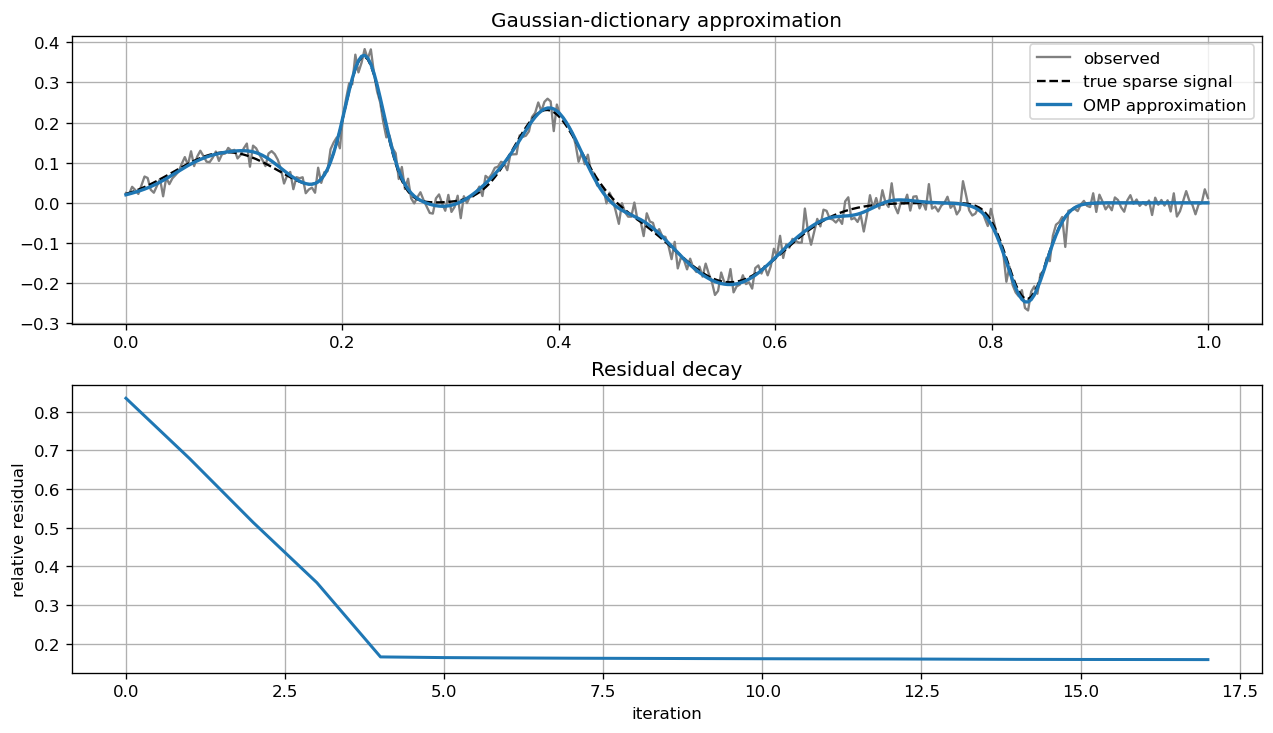

In [2]:
K = 18
res = y.copy()
S = []
coef = np.zeros(Phi.shape[1])
errs = []
for _ in range(K):
    corr = np.abs(Phi.T @ res)
    corr[S] = -1.0
    j = int(np.argmax(corr))
    S.append(j)
    A = Phi[:, S]
    cS, *_ = np.linalg.lstsq(A, y, rcond=None)
    res = y - A @ cS
    coef[:] = 0
    coef[S] = cS
    errs.append(np.linalg.norm(res) / (np.linalg.norm(y) + 1e-12))

y_hat = Phi @ coef

fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.0), constrained_layout=True)
axes[0].plot(t, y, color="0.5", lw=1.4, label="observed")
axes[0].plot(t, y0, "k--", lw=1.4, label="true sparse signal")
axes[0].plot(t, y_hat, color="tab:blue", lw=2.0, label="OMP approximation")
axes[0].set_title("Gaussian-dictionary approximation")
axes[0].legend()
axes[1].plot(errs, lw=1.8)
axes[1].set_title("Residual decay")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("relative residual")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- S. Mallat, Z. Zhang, "Matching Pursuits with Time-Frequency Dictionaries", IEEE TSP, 1993.
- Y. C. Pati, R. Rezaiifar, P. S. Krishnaprasad, "Orthogonal Matching Pursuit", Asilomar, 1993.
- J. A. Tropp, A. C. Gilbert, "Signal Recovery from Random Measurements via OMP", IEEE TIT, 2007.
- T. Hastie, R. Tibshirani, M. Wainwright, *Statistical Learning with Sparsity*, CRC Press, 2015.
